In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")



In [2]:
#  1. Generate Synthetic Dataset 

N = 500

genres      = ["Drama", "Comedy", "Action", "Horror", "Romance", "Thriller", "Documentary", "Sci-Fi"]
countries   = ["USA", "UK", "India", "South Korea", "Spain", "France", "Japan", "Canada"]
ratings     = ["G", "PG", "PG-13", "R", "TV-MA", "TV-14", "TV-PG"]
types       = ["Movie", "TV Show"]

genre_col   = np.random.choice(genres,   N, p=[0.22,0.18,0.15,0.08,0.10,0.10,0.07,0.10])
country_col = np.random.choice(countries, N, p=[0.30,0.12,0.18,0.10,0.08,0.07,0.08,0.07])
type_col    = np.random.choice(types,    N, p=[0.65, 0.35])
rating_col  = np.random.choice(ratings,  N, p=[0.04,0.08,0.20,0.25,0.22,0.14,0.07])
year_col    = np.random.randint(2010, 2024, N)



In [3]:
# Duration: movies in minutes, shows in seasons
duration_col = np.where(
    type_col == "Movie",
    np.random.randint(70, 180, N),
    np.random.randint(1, 8, N)
)



In [4]:
# IMDb-style score influenced by genre
base_score = {"Drama":7.1,"Comedy":6.8,"Action":6.9,"Horror":6.2,
              "Romance":6.5,"Thriller":7.0,"Documentary":7.4,"Sci-Fi":7.2}
score_col = np.array([base_score[g] + np.random.normal(0, 0.6) for g in genre_col])
score_col = np.clip(score_col, 4.0, 9.9).round(1)



In [5]:
# Views in millions
views_col = (score_col / 10) * np.random.uniform(5, 80, N)
views_col = views_col.round(2)

df = pd.DataFrame({
    "title":    [f"Title_{i}" for i in range(N)],
    "type":     type_col,
    "genre":    genre_col,
    "country":  country_col,
    "rating":   rating_col,
    "year":     year_col,
    "duration": duration_col,
    "score":    score_col,
    "views_M":  views_col
})



In [6]:
# Introduce some missing values (realistic)
df.loc[np.random.choice(df.index, 20, replace=False), "score"]   = np.nan
df.loc[np.random.choice(df.index, 10, replace=False), "country"] = np.nan

print("=" * 55)
print("  PROJECT 1: Netflix EDA")
print("=" * 55)



  PROJECT 1: Netflix EDA


In [7]:
#  2. Basic Info 
print("\n[1] Dataset Shape:", df.shape)
print("\n[2] First 5 rows:")
print(df.head())
print("\n[3] Missing values:")
print(df.isnull().sum())




[1] Dataset Shape: (500, 9)

[2] First 5 rows:
     title     type     genre      country rating  year  duration  score  \
0  Title_0    Movie    Comedy  South Korea      R  2021        75    6.6   
1  Title_1    Movie    Sci-Fi        India      R  2016       159    NaN   
2  Title_2  TV Show  Thriller           UK      G  2012         3    NaN   
3  Title_3  TV Show    Horror       France      R  2016         5    6.6   
4  Title_4  TV Show     Drama  South Korea      R  2021         3    8.3   

   views_M  
0     4.25  
1    48.21  
2    36.02  
3    37.93  
4    56.33  

[3] Missing values:
title        0
type         0
genre        0
country     10
rating       0
year         0
duration     0
score       20
views_M      0
dtype: int64


In [8]:
#  3. Handle Missing Values 
df["score"].fillna(df["score"].median(), inplace=True)
df["country"].fillna("Unknown", inplace=True)
print("\n[4] Missing values after cleaning:")
print(df.isnull().sum())




[4] Missing values after cleaning:
title       0
type        0
genre       0
country     0
rating      0
year        0
duration    0
score       0
views_M     0
dtype: int64


In [9]:
#  4. Summary Statistics 
print("\n[5] Summary statistics:")
print(df[["score", "views_M", "duration", "year"]].describe().round(2))




[5] Summary statistics:
        score  views_M  duration     year
count  500.00   500.00    500.00   500.00
mean     6.94    28.87     74.87  2016.46
std      0.66    15.58     62.92     3.94
min      4.60     3.23      1.00  2010.00
25%      6.50    15.26      5.00  2013.00
50%      7.00    28.16     87.50  2016.50
75%      7.40    40.92    129.00  2020.00
max      9.00    65.78    179.00  2023.00


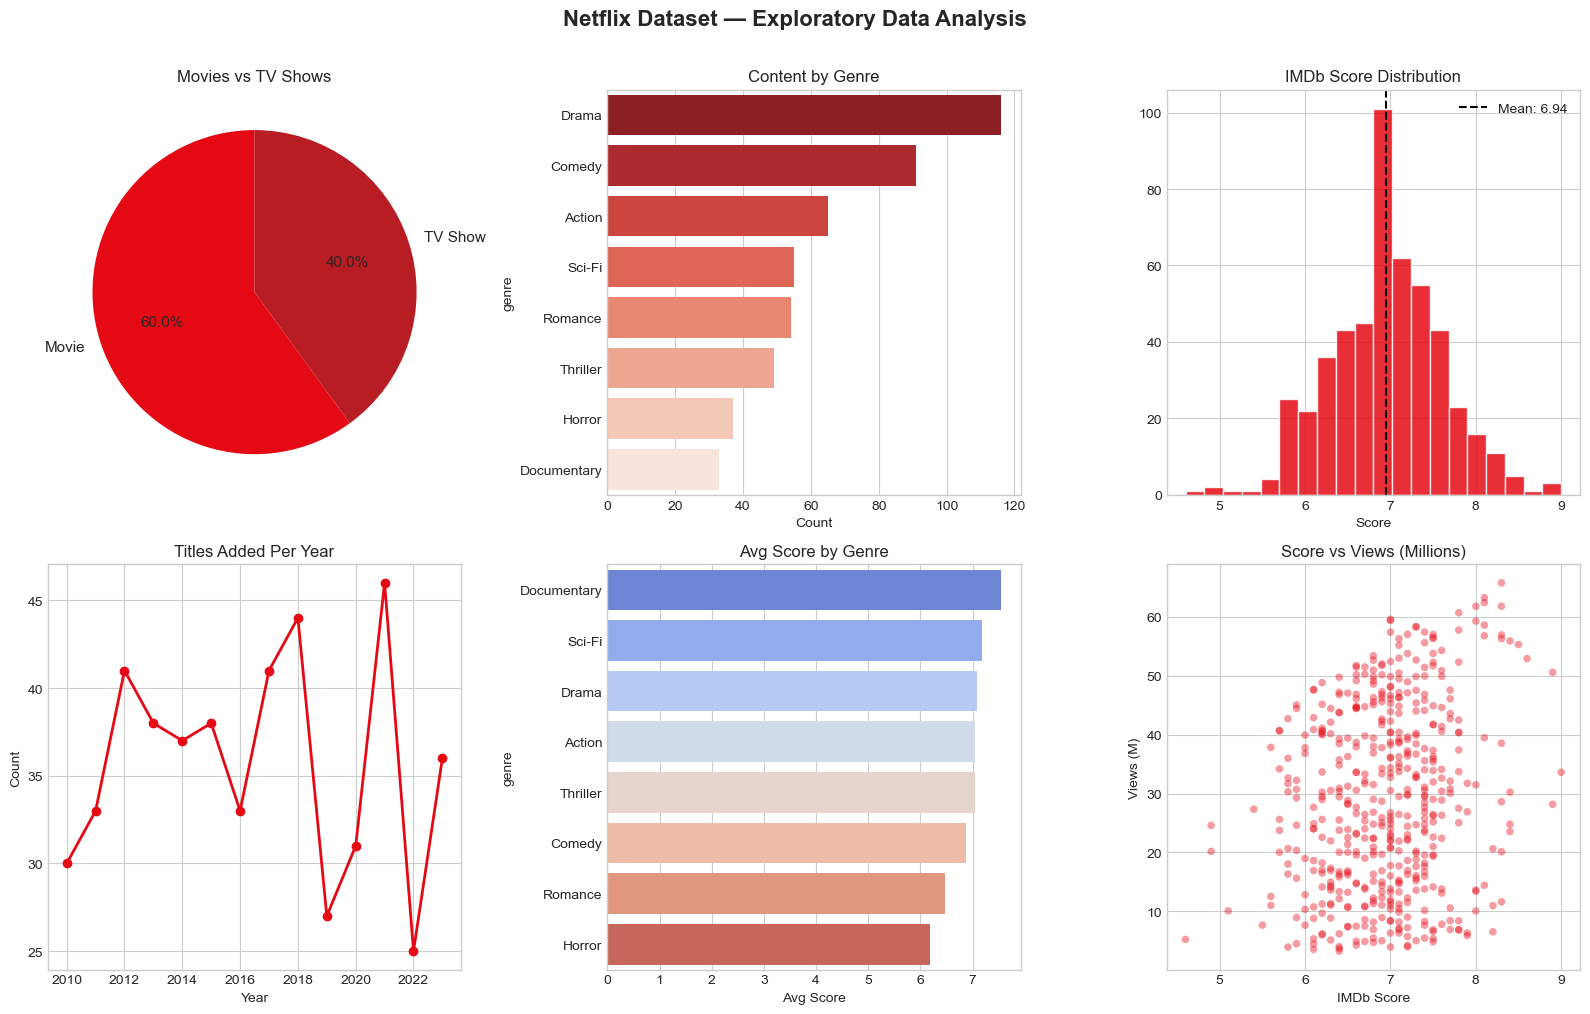


[6] Plot saved as netflix_eda.png


In [10]:
#  5. Visualizations 
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Netflix Dataset — Exploratory Data Analysis", fontsize=16, fontweight="bold", y=1.01)

# 5a. Content type distribution
type_counts = df["type"].value_counts()
axes[0, 0].pie(type_counts, labels=type_counts.index, autopct="%1.1f%%",
               colors=["#E50914", "#B81D24"], startangle=90, textprops={"fontsize":11})
axes[0, 0].set_title("Movies vs TV Shows")

# 5b. Genre distribution
genre_counts = df["genre"].value_counts()
sns.barplot(x=genre_counts.values, y=genre_counts.index, ax=axes[0, 1],
            palette="Reds_r")
axes[0, 1].set_title("Content by Genre")
axes[0, 1].set_xlabel("Count")

# 5c. Score distribution
axes[0, 2].hist(df["score"], bins=20, color="#E50914", edgecolor="white", alpha=0.85)
axes[0, 2].axvline(df["score"].mean(), color="black", linestyle="--", label=f"Mean: {df['score'].mean():.2f}")
axes[0, 2].set_title("IMDb Score Distribution")
axes[0, 2].set_xlabel("Score")
axes[0, 2].legend()

# 5d. Content added per year
year_counts = df["year"].value_counts().sort_index()
axes[1, 0].plot(year_counts.index, year_counts.values, marker="o", color="#E50914", linewidth=2)
axes[1, 0].set_title("Titles Added Per Year")
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("Count")

# 5e. Avg score by genre
avg_score = df.groupby("genre")["score"].mean().sort_values(ascending=False)
sns.barplot(x=avg_score.values, y=avg_score.index, ax=axes[1, 1], palette="coolwarm")
axes[1, 1].set_title("Avg Score by Genre")
axes[1, 1].set_xlabel("Avg Score")

# 5f. Score vs Views scatter
axes[1, 2].scatter(df["score"], df["views_M"], alpha=0.4, color="#E50914", edgecolors="none", s=30)
axes[1, 2].set_title("Score vs Views (Millions)")
axes[1, 2].set_xlabel("IMDb Score")
axes[1, 2].set_ylabel("Views (M)")

plt.tight_layout()
plt.savefig("netflix_eda.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n[6] Plot saved as netflix_eda.png")

In [11]:
#  6. Key Insights 
print("\n" + "=" * 55)
print("  KEY INSIGHTS")
print("=" * 55)
print(f"  Total titles      : {len(df)}")
print(f"  Movies            : {(df['type']=='Movie').sum()}")
print(f"  TV Shows          : {(df['type']=='TV Show').sum()}")
print(f"  Avg IMDb Score    : {df['score'].mean():.2f}")
print(f"  Top Genre         : {genre_counts.index[0]} ({genre_counts.iloc[0]} titles)")
print(f"  Most content from : {df['country'].value_counts().index[0]}")
print(f"  Best rated genre  : {avg_score.index[0]} ({avg_score.iloc[0]:.2f})")
print(f"  Peak year         : {year_counts.idxmax()} ({year_counts.max()} titles)")
print("=" * 55)
print("\nDone! Check netflix_eda.png for the plots.")


  KEY INSIGHTS
  Total titles      : 500
  Movies            : 300
  TV Shows          : 200
  Avg IMDb Score    : 6.94
  Top Genre         : Drama (116 titles)
  Most content from : USA
  Best rated genre  : Documentary (7.54)
  Peak year         : 2021 (46 titles)

Done! Check netflix_eda.png for the plots.
